In [1]:
import subprocess

subprocess.run([
    "scp milkv@192.168.50.195:~/sophgo/smokewagon-benchmarks/result-* ~/sophgo/smokewagon-benchmarks/"],
    shell=True, check=True)

CompletedProcess(args=['scp milkv@192.168.50.195:~/sophgo/smokewagon-benchmarks/result-* ~/sophgo/smokewagon-benchmarks/'], returncode=0)

In [60]:
from pathlib import Path

hash_names = {
    "24ac9404254c0ee7cccd53821e73af8c81fb9a46" : "xarray",
    "c277100ed866fc7f3cfae0b6172c5d3ed2ab5bb0" : "flat1GB",
    "eadff10a39c6faf2e486ed108e3a3bc4c2bb77b3" : "baseline",
}

import pandas as pd
import matplotlib.pyplot as plt

prefix = "result-microbenchmark-mmap-"
suffix = ".csv"
result_files = Path("~/sophgo/smokewagon-benchmarks").expanduser().glob(prefix + "*" + suffix)
dfs = []

for f in result_files:
    df = pd.read_csv(f, index_col=0)

    # column name faff
    label = f.name[len(prefix):-len(suffix)].split("-")
    col_label = tuple([label[1], label[0], hash_names.get(label[2])])
    df.columns = pd.MultiIndex.from_tuples([col_label])

    dfs.append(df)

df = pd.concat(dfs, axis=1)
# sorting columns now helps keep consistency in plotting later
df = df.reindex(sorted(df.columns), axis=1)
df.to_csv('smokewagon-microbenchmark-results.csv')
df

filebacked                                   membacked                 \
          inactive                 smokewagon         inactive                  
          baseline flat1GB  xarray    flat1GB xarray  baseline flat1GB xarray   
threads                                                                         
1           158711  149434  149309      57582  54959    106592   72613  73050   
2            96751   91016   90952      96206  94813     68593   62262  65956   
3            88716   82350   90410      73066  68656     60391   55177  58042   
4            82140   76667   89989      72717  64402     60595   52287  57823   
5            83135   76571   79273      71843  64167     56005   53163  54417   
...            ...     ...     ...        ...    ...       ...     ...    ...   
60           31588   31060   31057      65344  65287     25707   25377  25360   
61           31431   30769   30811      65485  65009     25622   25276  25193   
62           31113   30432   30497      64774  65699     25351   25007  24956   
63           30656   29909   30011      65071  62382     25070   24722  24660   
64           30158   29489   29586      64931  64848     24750   24390  24377   

                           
        smokewagon         
           flat1GB xarray  
threads                    
1            35742  35043  
2            60087  59232  
3            50529  49476  
4            47416  46630  
5            45156  49249  
...            ...    ...  
60           42515  40516  
61           42524  40674  
62           42405  40793  
63           42357  40579  
64           42125  38440  

[64 rows x 10 columns]

In [61]:
df.unstack().unstack()

threads                             1      2      3      4      5      6   \
filebacked inactive   baseline  158711  96751  88716  82140  83135  80721   
                      flat1GB   149434  91016  82350  76667  76571  75076   
                      xarray    149309  90952  90410  89989  79273  78753   
           smokewagon flat1GB    57582  96206  73066  72717  71843  72222   
                      xarray     54959  94813  68656  64402  64167  66896   
membacked  inactive   baseline  106592  68593  60391  60595  56005  54742   
                      flat1GB    72613  62262  55177  52287  53163  51546   
                      xarray     73050  65956  58042  57823  54417  52959   
           smokewagon flat1GB    35742  60087  50529  47416  45156  46656   
                      xarray     35043  59232  49476  46630  49249  47285   

threads                            7      8      9      10  ...     55     56  \
filebacked inactive   baseline  77390  74121  73762  71715  ...  33789  33251   
                      flat1GB   72823  70115  70854  69524  ...  32954  32510   
                      xarray    75662  73478  71237  70121  ...  33105  32611   
           smokewagon flat1GB   72221  72962  72438  72171  ...  65729  65152   
                      xarray    70537  70159  72686  72450  ...  66429  66127   
membacked  inactive   baseline  53066  51255  50013  49207  ...  27109  26739   
                      flat1GB   49870  48334  47705  46912  ...  26774  26447   
                      xarray    51428  49868  48329  47599  ...  26717  26356   
           smokewagon flat1GB   51076  50589  50194  49317  ...  42150  42489   
                      xarray    49781  48726  42038  45917  ...  40302  40072   

threads                            57     58     59     60     61     62  \
filebacked inactive   baseline  33065  32659  32192  31588  31431  31113   
                      flat1GB   32261  31903  31446  31060  30769  30432   
                      xarray    32355  31997  31543  31057  30811  30497   
           smokewagon flat1GB   65260  65160  65549  65344  65485  64774   
                      xarray    65664  65902  65310  65287  65009  65699   
membacked  inactive   baseline  26640  26362  26050  25707  25622  25351   
                      flat1GB   26326  26056  25739  25377  25276  25007   
                      xarray    26256  25990  25668  25360  25193  24956   
           smokewagon flat1GB   42777  42744  42476  42515  42524  42405   
                      xarray    39252  39681  40637  40516  40674  40793   

threads                            63     64  
filebacked inactive   baseline  30656  30158  
                      flat1GB   29909  29489  
                      xarray    30011  29586  
           smokewagon flat1GB   65071  64931  
                      xarray    62382  64848  
membacked  inactive   baseline  25070  24750  
                      flat1GB   24722  24390  
                      xarray    24660  24377  
           smokewagon flat1GB   42357  42125  
                      xarray    40579  38440  

[10 rows x 64 columns]

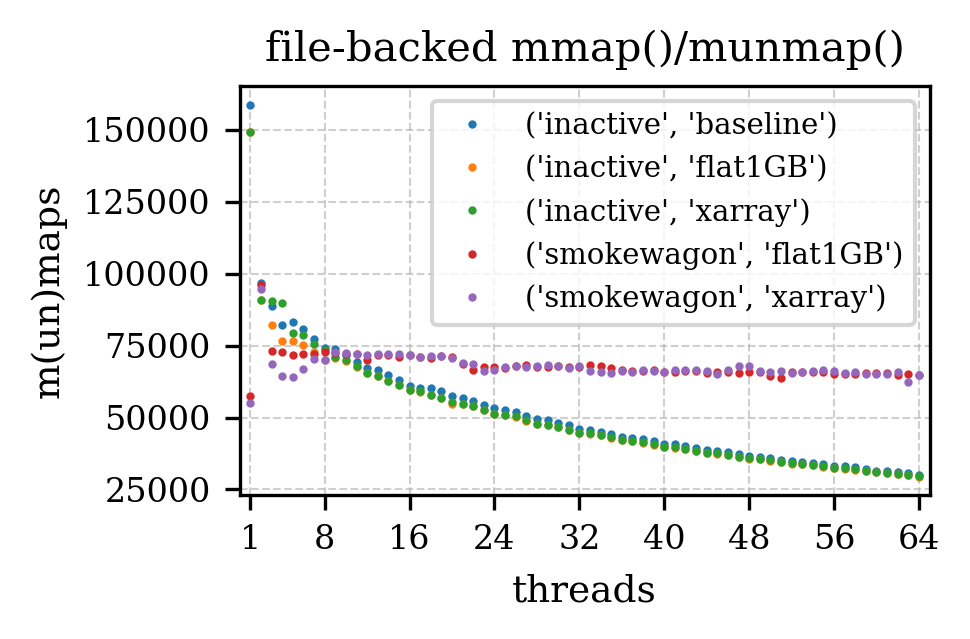

In [62]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(3.3, 2.2))  # ACM single-column width
ax.plot(df['filebacked'].index, df['filebacked'].values, '.', markersize=2)
ax.set_title("file-backed mmap()/munmap()")
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(df['filebacked'].columns, frameon=True)
plt.tight_layout()
plt.savefig("microbenchmark-mmap-filebacked.pdf", bbox_inches="tight")

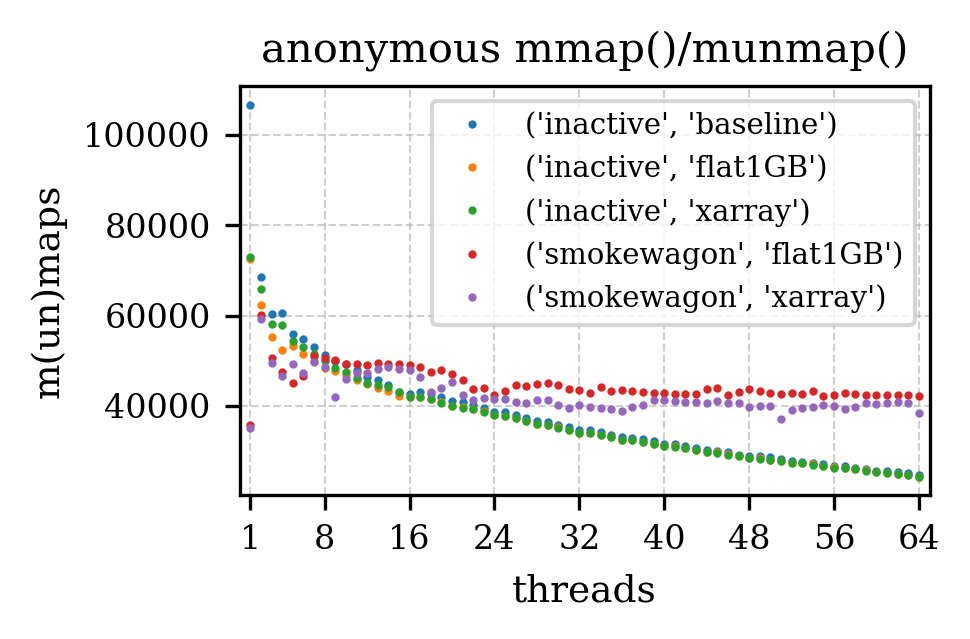

In [63]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(3.3, 2.2))  # ACM single-column width
ax.plot(df['membacked'].index, df['membacked'].values, '.', markersize=2)
ax.set_title("anonymous mmap()/munmap()")
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(df['membacked'].columns, frameon=True)
plt.tight_layout()
plt.savefig("microbenchmark-mmap-membacked.pdf", bbox_inches="tight")